# Coding an LLM architecture

In [1]:
GPT_CONFIG_124m = {
    "vocab_size": 50_257,   # number of unique token IDs the tokenizer/model supports
    "context_length": 1024, # maximum number of tokens the model can process at once
    "emb_dim": 768,         # size of each token and postional embedding
    "n_heads": 12,          # number of attention heads in each multi-head attention layer
    "n_layers": 12,         # number of transformer blocks stacked in the model
    "drop_rate": 0.1,       # dropout probability used for regularization
    "qkv_bias": False,      # whether query/key/value linear layers use bias terms.
}

In [2]:
import torch
import torch.nn as nn

class DummyGTPModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    
    def forward(self, x):
        return x
    
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    
    def forward(self, x):
        return x

In [5]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
text1 = "Every effort moves you"
text2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(text1)))
batch.append(torch.tensor(tokenizer.encode(text2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)



(process:27632): Pango-WARNING **: 22:50:01.067: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


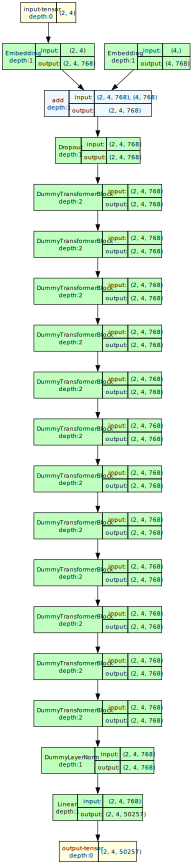

In [20]:
import torchview as tv
torch.manual_seed(123)
model = DummyGTPModel(GPT_CONFIG_124m)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)
mock_batch = torch.randint(0, GPT_CONFIG_124m["vocab_size"], (2,4), dtype=torch.long)
graph_model = tv.draw_graph(model, input_data=batch)
graph_model.visual_graph

# Normalizing activations with layer normalization


In [22]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [23]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [24]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [25]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [26]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale= nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

Mean:
 tensor([[     0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)



(process:5952): Pango-WARNING **: 22:22:08.483: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


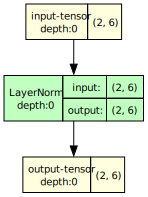

In [30]:
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)

print("Mean:\n", mean)
print("Variance:\n", var)

graph_ln = tv.draw_graph(ln, input_data=out)
graph_ln.visual_graph

# Implementing a feed forward network with GELU activations


In [32]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

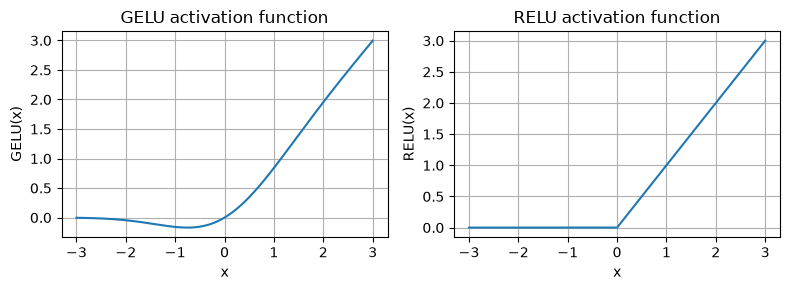

In [47]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 5000)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "RELU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [51]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], cfg["emb_dim"] * 4),
            GELU(),
            nn.Linear(cfg["emb_dim"] * 4, cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)
    

torch.Size([2, 3, 768])



(process:23532): Pango-WARNING **: 22:57:15.920: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


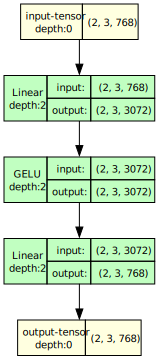

In [53]:
ffn = FeedForward(GPT_CONFIG_124m)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)
ffn_view = tv.draw_graph(ffn, input_data=x)
ffn_view.visual_graph

# Adding shortcut connections 

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
        ])
    
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [55]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes=layer_sizes, use_shortcut=False)

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


In [56]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0005546716856770217
layers.1.0.weight has gradient mean of 0.00033483587321825325
layers.2.0.weight has gradient mean of 0.0020371272694319487
layers.3.0.weight has gradient mean of 0.004004639573395252
layers.4.0.weight has gradient mean of 0.004936343524605036


c:\Users\CF2\Desktop\manning1\llm-from-scratch\.venv\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [ ]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes=layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.6295759677886963
layers.1.0.weight has gradient mean of 0.5254611968994141
layers.2.0.weight has gradient mean of 0.7470273971557617
layers.3.0.weight has gradient mean of 0.44738197326660156
layers.4.0.weight has gradient mean of 0.5909448862075806


c:\Users\CF2\Desktop\manning1\llm-from-scratch\.venv\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# Connecting attention and linear layers in a transformer block

In [63]:
import importnb 
with importnb.Notebook():
    from chapter3 import MultiHeaddAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeaddAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_lenght=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout()
    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

Input shape torch.Size([2, 4, 768])
Output shape torch.Size([2, 4, 768])



(process:15108): Pango-WARNING **: 23:49:10.128: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


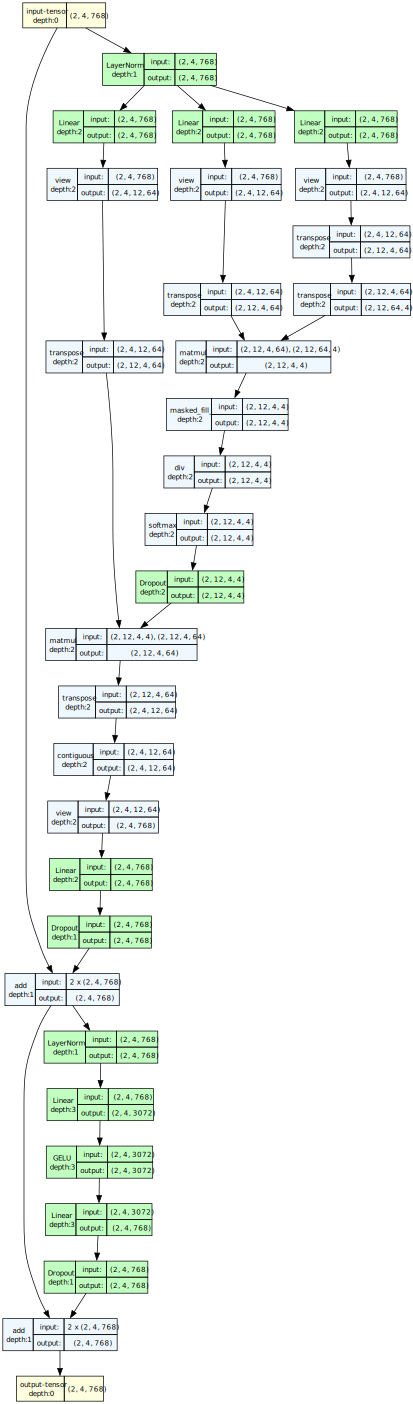

In [66]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124m)
output = block(x)
print("Input shape", x.shape)
print("Output shape", x.shape)
gpt_model_view = tv.draw_graph(block, input_data=x)
gpt_model_view.visual_graph

# Coding the GPT model

In [69]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm =  LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
    
    def forward(self, in_idx):
        batch, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


In [70]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124m)
out = model(batch)
print("Input batch: \n", batch)
print("Output shape:\n", out.shape)
print(out)

Input batch: 
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape:
 torch.Size([2, 4, 50257])
tensor([[[ 0.1780,  0.5136,  0.0223,  ..., -0.2160, -0.2245, -0.2982],
         [ 0.7813, -0.3469, -0.2694,  ..., -0.0059,  0.1868, -0.2620],
         [ 0.5487,  0.2984, -0.3621,  ...,  0.5579, -0.5498, -0.5458],
         [-0.1983,  0.5183, -0.2493,  ...,  0.9628,  0.1294, -0.6464]],

        [[ 0.2459, -0.4062, -0.3501,  ..., -0.1530,  0.2560, -0.3131],
         [ 0.1549,  0.0757, -0.2587,  ...,  0.5052,  0.1236,  0.1863],
         [ 0.3079,  0.3713,  0.0026,  ...,  0.1825, -0.1044,  0.0212],
         [ 0.1024, -0.2715,  0.3712,  ...,  1.2223,  0.1737,  0.0956]]],
       grad_fn=<UnsafeViewBackward0>)


In [75]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

total_params_in_on_tb = sum(p.numel() for p in block.parameters())
print(f"Total number of params in a transformer block: {total_params_in_on_tb:,}")

total_params_in_ff = sum(p.numel() for p in ffn.parameters())
print(f"Total number of params in a ffn: {total_params_in_ff:,}")

Total number of parameters: 163,009,536
Total number of params in a transformer block: 7,085,568
Total number of params in a ffn: 4,722,432


In [76]:
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


In [ ]:

GPT_CONFIG_MEDIUM = {
    "vocab_size": GPT_CONFIG_124m["vocab_size"],
    "context_length":GPT_CONFIG_124m["context_length"],
    "emb_dim": 1024,
    "n_heads": 16,
    "n_layers": 24,
    "drop_rate": GPT_CONFIG_124m["drop_rate"],
    "qkv_bias": GPT_CONFIG_124m["qkv_bias"]
}

GPT_CONFIG_LARGE = {
    "vocab_size": GPT_CONFIG_124m["vocab_size"],
    "context_length":GPT_CONFIG_124m["context_length"],
    "emb_dim": 1280,
    "n_heads": 20,
    "n_layers": 36,
    "drop_rate": GPT_CONFIG_124m["drop_rate"],
    "qkv_bias": GPT_CONFIG_124m["qkv_bias"],
}

GPT_CONFIG_EXTRA_LARGE = {
    "vocab_size": GPT_CONFIG_124m["vocab_size"],
    "context_length":GPT_CONFIG_124m["context_length"],
    "emb_dim": 1280,
    "n_heads": 20,
    "n_layers": 36,
    "drop_rate": GPT_CONFIG_124m["drop_rate"],
    "qkv_bias": GPT_CONFIG_124m["qkv_bias"],
}

model_medium = GPTModel(GPT_CONFIG_MEDIUM)
model_large = GPTModel(GPT_CONFIG_LARGE)
model_extra_large = GPTModel(GPT_CONFIG_EXTRA_LARGE)
total_params_for_m = sum(p.numel() for p in model_medium.parameters())
total_params_for_large = sum(p.numel() for p in model_large.parameters())
total_params_for_extra_large = sum(p.numel() for p in model_extra_large.parameters())
print(f"Number of params in gpt medium: {total_params_for_m}")
print(f"Number of parameters in gpt large: {total_params_for_large}")
print(f"Number of parameters in gpt extra large {total_params_for_extra_large}")

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
Number of params in gpt medium: 406212608
Number of parameters in gpt large: 838220800
Number of parameters in gpt extra large 838220800


In [92]:
import gc
# del model_medium
# del model_large
# del model_extra_large
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

total_params_in_on_tb = sum(p.numel() for p in block.parameters())
print(f"Total number of params in a transformer block: {total_params_in_on_tb:,}")

total_params_in_ff = sum(p.numel() for p in ffn.parameters())
print(f"Total number of params in a ffn: {total_params_in_ff:,}")

Total number of parameters: 163,009,536
Total number of params in a transformer block: 7,085,568
Total number of params in a ffn: 4,722,432


# Generating text

In [94]:
def generate_text_simple(model, idx, max_new_tokens, context_size): 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1 )
    return idx

In [96]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [ ]:
model.eval()
out = generate_text_simple(model=model, idx=encoded_tensor, max_new_tokens=6, context_size=GPT_CONFIG_124m["context_length"])

In [99]:
print("Print out:", out)
print("Out length:", len(out[0]))


Print out: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Out length: 10


In [100]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
